<a href="https://colab.research.google.com/github/siddhartha-sai-17/Anomaleydetection/blob/main/CEIP_CVR_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
# ==============================
# 0️⃣ Imports & Setup
# ==============================
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn preprocessing, models & metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Advanced models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
train_path = '/content/train.parquet'
test_path = '/content/test.parquet'
sub_path = '/content/sample_submission.parquet'

train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sample_sub = pd.read_parquet(sub_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
display(train.head())

# Missing values
print(train.isnull().sum())

# Target distribution
print(train['target'].value_counts(normalize=True))

Train shape: (1639424, 7)
Test shape: (409856, 7)


,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64
target
0    0.991437
1    0.008563
Name: proportion, dtype: float64


In [ ]:
# Numeric columns
num_cols = ['X1','X2','X3','X4','X5']

# Impute missing values
imputer = SimpleImputer(strategy='median')
train[num_cols] = imputer.fit_transform(train[num_cols])
test[num_cols] = imputer.transform(test[num_cols])

# Scale features
scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

# Extract time features
for df in [train, test]:
    df['Date'] = pd.to_datetime(df['Date'])
    df['hour'] = df['Date'].dt.hour
    df['dayofweek'] = df['Date'].dt.dayofweek

# Row-level stats
for df in [train, test]:
    df['sensor_mean'] = df[num_cols].mean(axis=1)
    df['sensor_std'] = df[num_cols].std(axis=1)
    df['sensor_max'] = df[num_cols].max(axis=1)
    df['sensor_min'] = df[num_cols].min(axis=1)

In [ ]:
features = num_cols + ['hour','dayofweek','sensor_mean','sensor_std','sensor_max','sensor_min']
X = train[features]
y = train['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

y_train = y_train.astype(int)
y_val = y_val.astype(int)

In [ ]:
models = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1),
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    print(f"{name} - F1-score (Anomalies): {f1:.3f}")

LogisticRegression - F1-score (Anomalies): 0.100
DecisionTree - F1-score (Anomalies): 0.287
KNN - F1-score (Anomalies): 0.264


In [ ]:
# XGBoost
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(), random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_val)
print("XGBoost F1-score (Anomalies):", f1_score(y_val, y_pred_xgb))

# LightGBM
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, class_weight='balanced', random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_val)
print("LightGBM F1-score (Anomalies):", f1_score(y_val, y_pred_lgbm))

# CatBoost
cat = CatBoostClassifier(iterations=200, learning_rate=0.05, class_weights=[1, 100], verbose=0, random_seed=42)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_val)
print("CatBoost F1-score (Anomalies):", f1_score(y_val, y_pred_cat))

XGBoost F1-score (Anomalies): 0.1107708576590073
[LightGBM] [Info] Number of positive: 11230, number of negative: 1300309
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066961 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1650
[LightGBM] [Info] Number of data points in the train set: 1311539, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM F1-score (Anomalies): 0.14279371774238303
CatBoost F1-score (Anomalies): 0.12100701207635373


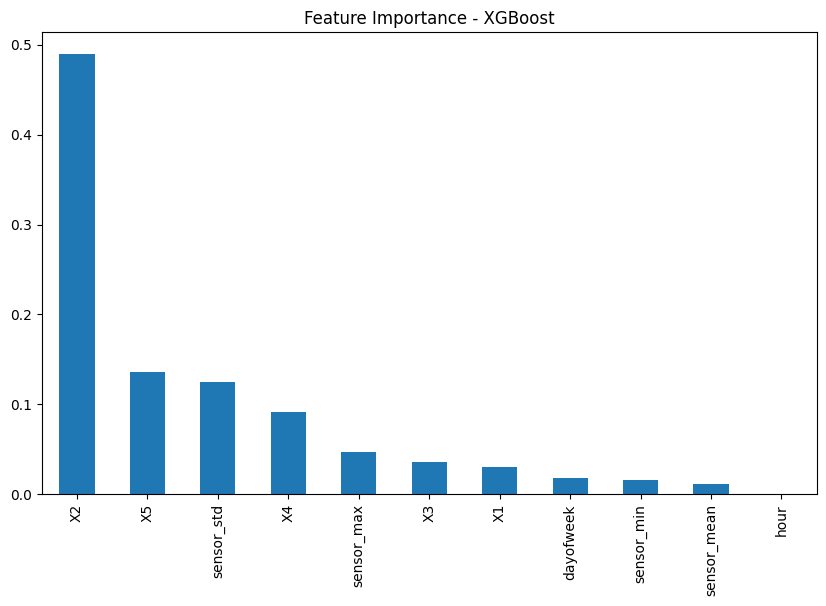

In [ ]:
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title("Feature Importance - XGBoost")
plt.show()

In [ ]:
X_test = test[features]
test_preds = xgb.predict(X_test)  # Using best performing model (XGBoost)

submission = pd.DataFrame({'target': test_preds})
submission.to_parquet("submission.parquet", index=False)
print(f"Submission saved with {len(submission)} rows")

Submission saved with 409856 rows



===== LogisticRegression =====
Classification Report:

              precision    recall  f1-score   support

           0     0.9988    0.8646    0.9268    325077
           1     0.0530    0.8782    0.1000      2808

    accuracy                         0.8647    327885
   macro avg     0.5259    0.8714    0.5134    327885
weighted avg     0.9907    0.8647    0.9198    327885



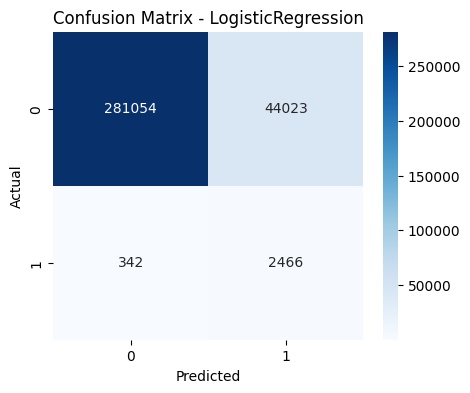

F1 Score for Anomalies: 0.1000
ROC AUC: 0.9435

===== DecisionTree =====
Classification Report:

              precision    recall  f1-score   support

           0     0.9941    0.9923    0.9932    325077
           1     0.2622    0.3166    0.2868      2808

    accuracy                         0.9865    327885
   macro avg     0.6281    0.6544    0.6400    327885
weighted avg     0.9878    0.9865    0.9871    327885



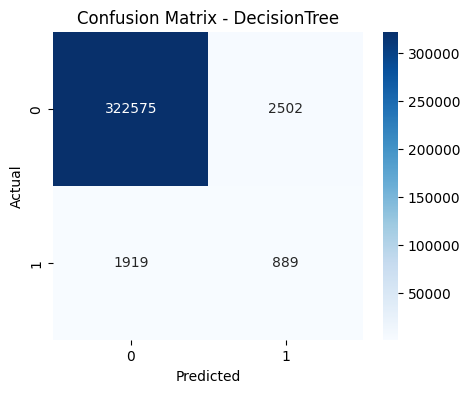

F1 Score for Anomalies: 0.2868
ROC AUC: 0.6549

===== KNN =====
Classification Report:

              precision    recall  f1-score   support

           0     0.9929    0.9991    0.9960    325077
           1     0.6111    0.1684    0.2641      2808

    accuracy                         0.9920    327885
   macro avg     0.8020    0.5838    0.6300    327885
weighted avg     0.9896    0.9920    0.9897    327885



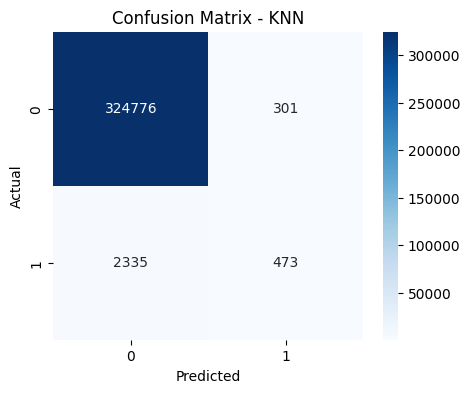

F1 Score for Anomalies: 0.2641
ROC AUC: 0.7266

===== RandomForest =====
Classification Report:

              precision    recall  f1-score   support

           0     0.9936    0.9965    0.9950    325077
           1     0.3848    0.2539    0.3059      2808

    accuracy                         0.9901    327885
   macro avg     0.6892    0.6252    0.6505    327885
weighted avg     0.9884    0.9901    0.9891    327885



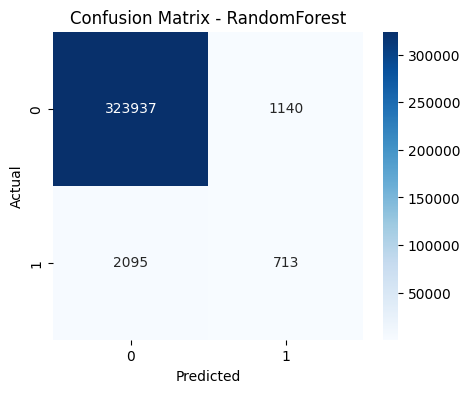

F1 Score for Anomalies: 0.3059
ROC AUC: 0.8573

===== XGBoost =====
Classification Report:

              precision    recall  f1-score   support

           0     0.9990    0.8767    0.9339    325077
           1     0.0590    0.8953    0.1108      2808

    accuracy                         0.8769    327885
   macro avg     0.5290    0.8860    0.5223    327885
weighted avg     0.9909    0.8769    0.9268    327885



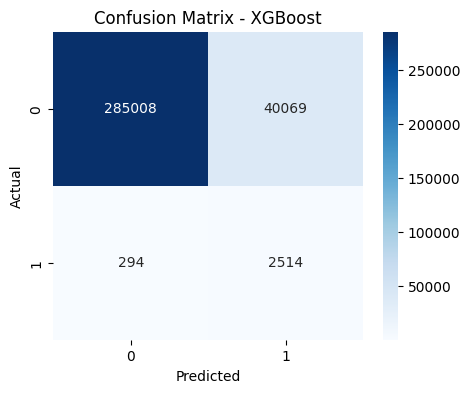

F1 Score for Anomalies: 0.1108
ROC AUC: 0.9569

===== LightGBM =====
[LightGBM] [Info] Number of positive: 11230, number of negative: 1300309
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.152520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1650
[LightGBM] [Info] Number of data points in the train set: 1311539, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Classification Report:

              precision    recall  f1-score   support

           0     0.9992    0.9057    0.9502    325077
           1     0.0774    0.9163    0.1428      2808

    accuracy                         0.9058    327885
   macro avg     0.5383    0.9110    0.5465    327885
weighted avg     0.9913    0.9058    0.9432    327885



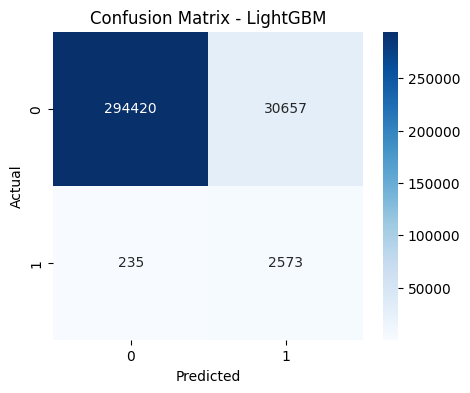

F1 Score for Anomalies: 0.1428
ROC AUC: 0.9709

===== CatBoost =====
Classification Report:

              precision    recall  f1-score   support

           0     0.9989    0.8899    0.9413    325077
           1     0.0649    0.8850    0.1210      2808

    accuracy                         0.8899    327885
   macro avg     0.5319    0.8875    0.5311    327885
weighted avg     0.9909    0.8899    0.9342    327885



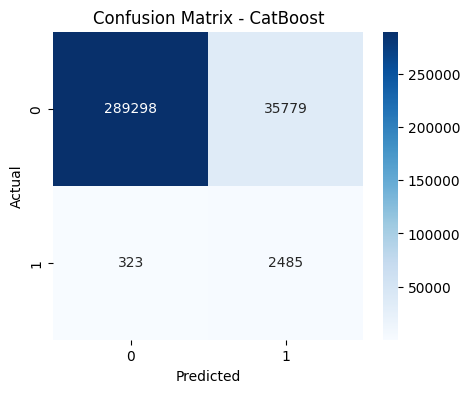

F1 Score for Anomalies: 0.1210
ROC AUC: 0.9571


In [ ]:
# ==============================
# Model Evaluation Metrics
# ==============================
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve

models = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1),
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(), random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=200, learning_rate=0.05, class_weight='balanced', random_state=42),
    "CatBoost": CatBoostClassifier(iterations=200, learning_rate=0.05, class_weights=[1, 100], verbose=0, random_seed=42)
}

for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_val)

    # Classification metrics
    print("Classification Report:\n")
    print(classification_report(y_val, y_pred, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # F1 score for anomalies specifically
    f1_anomaly = f1_score(y_val, y_pred, pos_label=1)
    print(f"F1 Score for Anomalies: {f1_anomaly:.4f}")

    # ROC AUC (if model supports probability)
    try:
        y_proba = model.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_proba)
        print(f"ROC AUC: {auc:.4f}")
    except:
        print("ROC AUC: Not available (model does not support predict_proba)")

In [ ]:
# ==============================
# Optimized Anomaly Detection Pipeline
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1️⃣ Load Data (Kaggle Paths)
# ------------------------------
train_path = '/content/train.parquet'
test_path = '/content/test.parquet'

train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

# ------------------------------
# 2️⃣ Preprocessing
# ------------------------------
num_cols = ['X1','X2','X3','X4','X5']

# Impute missing values
imputer = SimpleImputer(strategy='median')
train[num_cols] = imputer.fit_transform(train[num_cols])
test[num_cols] = imputer.transform(test[num_cols])

# Scale
scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

# Date features
for df in [train, test]:
    df['Date'] = pd.to_datetime(df['Date'])
    df['hour'] = df['Date'].dt.hour
    df['dayofweek'] = df['Date'].dt.dayofweek

# Row stats
for df in [train, test]:
    df['sensor_mean'] = df[num_cols].mean(axis=1)
    df['sensor_std'] = df[num_cols].std(axis=1)
    df['sensor_max'] = df[num_cols].max(axis=1)
    df['sensor_min'] = df[num_cols].min(axis=1)
    # Additional features
    df['X1_X2_diff'] = df['X1'] - df['X2']
    df['X3_X4_diff'] = df['X3'] - df['X4']
    df['X1_X5_ratio'] = df['X1'] / (df['X5'] + 1e-6)

# ------------------------------
# 3️⃣ Train-Validation Split
# ------------------------------
features = num_cols + ['hour','dayofweek','sensor_mean','sensor_std','sensor_max','sensor_min',
                       'X1_X2_diff','X3_X4_diff','X1_X5_ratio']

X = train[features]
y = train['target'].astype(int)  # ensure integer
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ------------------------------
# 4️⃣ Train Models
# ------------------------------
# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05,
                    scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
                    random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

# ------------------------------
# 5️⃣ Ensemble Predictions with Threshold Tuning
# ------------------------------
# Predict probabilities
rf_proba = rf.predict_proba(X_val)[:,1]
xgb_proba = xgb.predict_proba(X_val)[:,1]

# Simple ensemble: average probabilities
y_proba_ensemble = (rf_proba + xgb_proba)/2

# Tune threshold
threshold = 0.3
y_pred_ensemble = (y_proba_ensemble >= threshold).astype(int)

# ------------------------------
# 6️⃣ Evaluation
# ------------------------------
print("Classification Report (Ensemble, Threshold=0.3):\n")
print(classification_report(y_val, y_pred_ensemble, digits=4))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_ensemble)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble")
plt.show()

# F1 for anomalies
f1_anomaly = f1_score(y_val, y_pred_ensemble, pos_label=1)
print(f"F1 Score for Anomalies: {f1_anomaly:.4f}")

# ROC AUC
auc = roc_auc_score(y_val, y_proba_ensemble)
print(f"ROC AUC: {auc:.4f}")

# ------------------------------
# 7️⃣ Predict on Test Set
# ------------------------------
rf_test_proba = rf.predict_proba(test[features])[:,1]
xgb_test_proba = xgb.predict_proba(test[features])[:,1]
y_test_proba = (rf_test_proba + xgb_test_proba)/2

y_test_pred = (y_test_proba >= threshold).astype(int)

# ------------------------------
# 8️⃣ Submission
# ------------------------------
submission = pd.DataFrame({'target': y_test_pred})
submission.to_parquet("submission.parquet", index=False)
print(f"Submission saved with {len(submission)} rows")

KeyboardInterrupt: 

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00


0:	learn: 0.8668372	test: 0.8669670	best: 0.8669670 (0)	total: 534ms	remaining: 2m 39s
100:	learn: 0.8975717	test: 0.8970797	best: 0.8970797 (100)	total: 39.5s	remaining: 1m 17s
200:	learn: 0.9091440	test: 0.9019835	best: 0.9024214 (192)	total: 1m 18s	remaining: 38.7s
299:	learn: 0.9196764	test: 0.9057029	best: 0.9063543 (273)	total: 1m 57s	remaining: 0us

bestTest = 0.9063542725
bestIteration = 273

Shrink model to first 274 iterations.
Optimal Threshold: 0.7000000000000002, Best F1: 0.7726

Classification Report (Ensemble)
              precision    recall  f1-score   support

           0     0.9977    0.9986    0.9981    325077
           1     0.8156    0.7340    0.7726      2808

    accuracy                         0.9963    327885
   macro avg     0.9066    0.8663    0.8854    327885
weighted avg     0.9961    0.9963    0.9962    327885



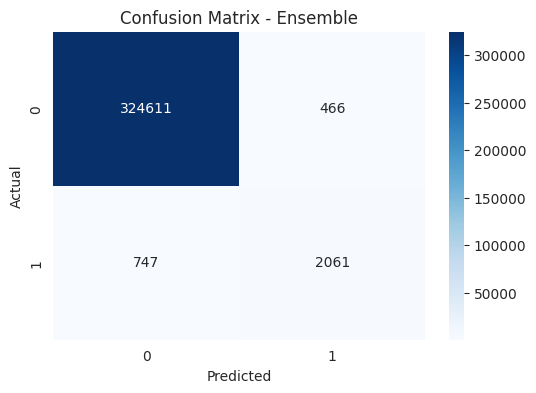

F1 Score for Anomalies: 0.7726
ROC AUC: 0.9922
Submission file created with 409856 rows


,target
0,0
1,0
2,0
3,0
4,0


In [ ]:
# =========================================
# CEIP CVR - Optimized Anomaly Detection
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
# ------------------------------
# 1️⃣ Load Data (Kaggle Input Paths)
# ------------------------------
train_path = '/content/train.parquet'
test_path = '/content/test.parquet'

train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

# Ensure target is integer
train['target'] = train['target'].astype(int)

# ------------------------------
# 2️⃣ Feature Engineering
# ------------------------------
epsilon = 1e-10
num_cols = ['X1','X2','X3','X4','X5']

for df in [train, test]:
    # Row stats
    df['sensor_mean'] = df[num_cols].mean(axis=1)
    df['sensor_std'] = df[num_cols].std(axis=1)
    df['sensor_max'] = df[num_cols].max(axis=1)
    df['sensor_min'] = df[num_cols].min(axis=1)
    # Log transform
    df['X3_log'] = np.log1p(df['X3'] + epsilon)
    df['X4_log'] = np.log1p(df['X4'] + epsilon)
    # Interaction / ratios
    df['X1_X2'] = df['X1'] * df['X2']
    df['X4_X5'] = df['X4'] * df['X5']
    df['X1_X2_ratio'] = df['X1'] / (df['X2'] + epsilon)
    # Sensor differences
    df['X1_X2_diff'] = df['X1'] - df['X2']
    df['X3_X4_diff'] = df['X3'] - df['X4']
    df['X1_X5_ratio'] = df['X1'] / (df['X5'] + epsilon)
    # Date features
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek

# Drop original Date
train.drop('Date', axis=1, inplace=True)
test.drop('Date', axis=1, inplace=True)

# ------------------------------
# 3️⃣ Train-Validation Split
# ------------------------------
features = [c for c in train.columns if c != 'target']

X = train[features]
y = train['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ------------------------------
# 4️⃣ Model Training - Ensemble
# ------------------------------
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

# CatBoost
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function='Logloss',
    eval_metric='F1',
    class_weights=[1, 20],
    verbose=100,
    random_state=42
)
cat.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=100)

# ------------------------------
# 5️⃣ Ensemble Predictions on Validation
# ------------------------------
rf_val_proba = rf.predict_proba(X_val)[:,1]
xgb_val_proba = xgb.predict_proba(X_val)[:,1]
cat_val_proba = cat.predict_proba(X_val)[:,1]

# Average probabilities
y_val_proba = (rf_val_proba + xgb_val_proba + cat_val_proba) / 3

# Threshold tuning
thresholds = np.arange(0.1, 1.0, 0.05)
best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_t = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Optimal Threshold: {best_threshold}, Best F1: {best_f1:.4f}")

# ------------------------------
# 6️⃣ Evaluate Ensemble on Validation
# ------------------------------
y_val_pred = (y_val_proba >= best_threshold).astype(int)

print("\nClassification Report (Ensemble)")
print(classification_report(y_val, y_val_pred, digits=4))

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble")
plt.show()

f1_anomaly = f1_score(y_val, y_val_pred, pos_label=1)
auc = roc_auc_score(y_val, y_val_proba)

print(f"F1 Score for Anomalies: {f1_anomaly:.4f}")
print(f"ROC AUC: {auc:.4f}")

# ------------------------------
# 7️⃣ Predict on Test Set & Submission
# ------------------------------
rf_test_proba = rf.predict_proba(test[features])[:,1]
xgb_test_proba = xgb.predict_proba(test[features])[:,1]
cat_test_proba = cat.predict_proba(test[features])[:,1]

y_test_proba = (rf_test_proba + xgb_test_proba + cat_test_proba)/3
y_test_pred = (y_test_proba >= best_threshold).astype(int)

submission = pd.DataFrame({'target': y_test_pred})
submission.to_csv("submission.csv", index=False)
print(f"Submission file created with {len(submission)} rows")

display(submission.head())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

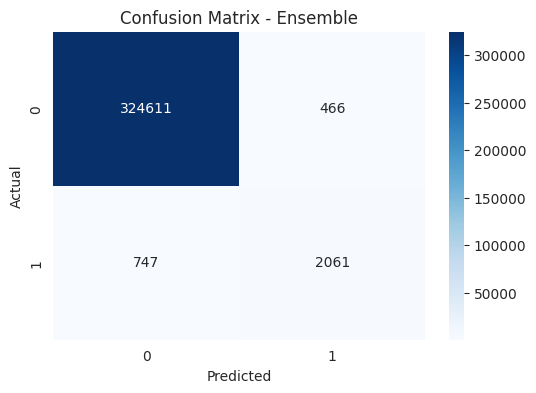

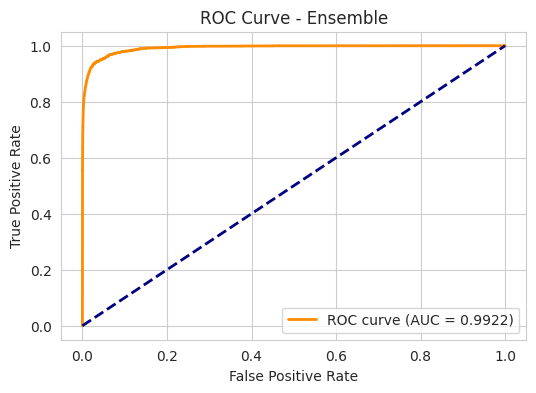

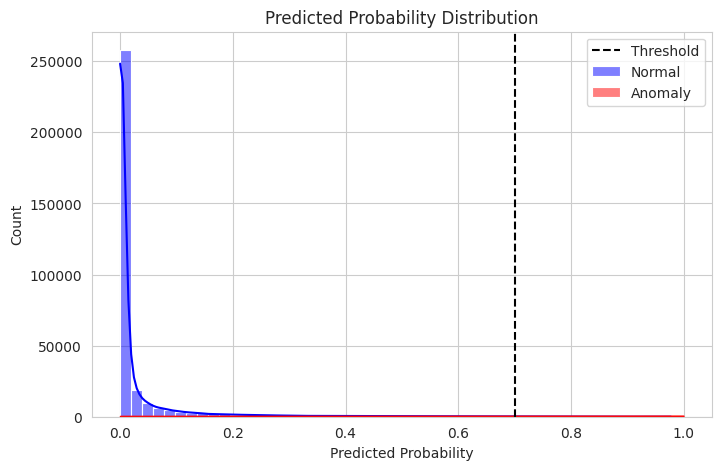

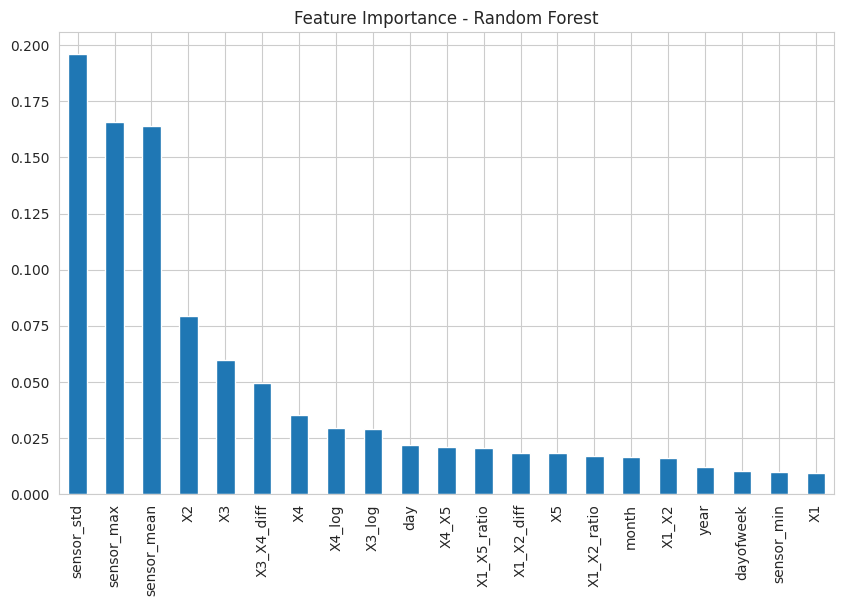

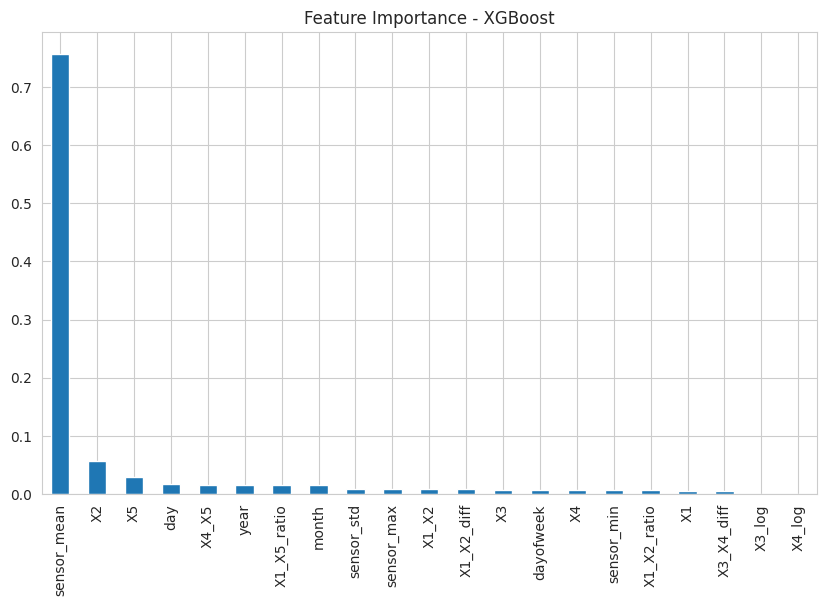

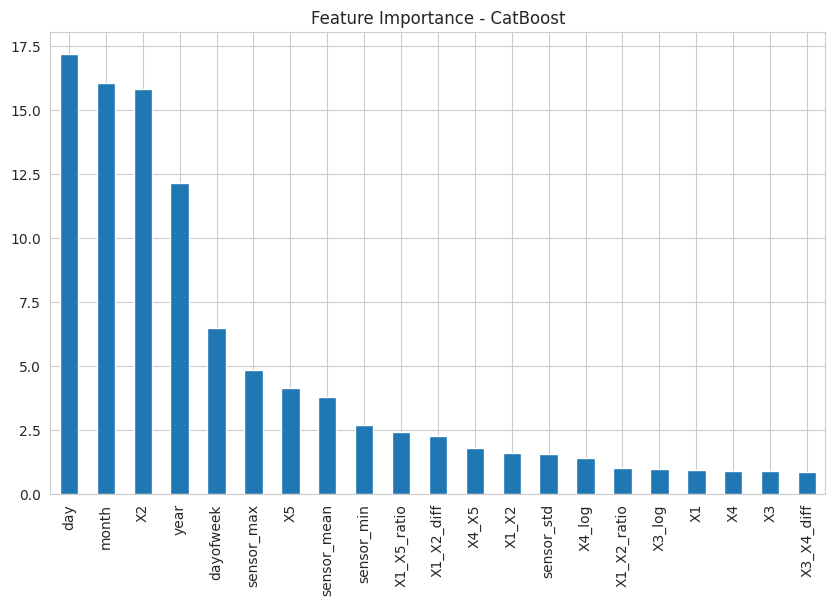

In [ ]:
# =========================================
# Ensemble Visualizations
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1️⃣ Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble")
plt.show()

# ------------------------------
# 2️⃣ ROC Curve
# ------------------------------
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ensemble")
plt.legend(loc="lower right")
plt.show()

# ------------------------------
# 3️⃣ Predicted Probability Distribution
# ------------------------------
plt.figure(figsize=(8,5))
sns.histplot(y_val_proba[y_val==0], color='blue', label='Normal', bins=50, kde=True)
sns.histplot(y_val_proba[y_val==1], color='red', label='Anomaly', bins=50, kde=True)
plt.axvline(best_threshold, color='black', linestyle='--', label='Threshold')
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

# ------------------------------
# 4️⃣ Feature Importances
# ------------------------------
# Random Forest
rf_feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
rf_feat_imp.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.show()

# XGBoost
xgb_feat_imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
xgb_feat_imp.plot(kind='bar')
plt.title("Feature Importance - XGBoost")
plt.show()

# CatBoost
cat_feat_imp = pd.Series(cat.get_feature_importance(), index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
cat_feat_imp.plot(kind='bar')
plt.title("Feature Importance - CatBoost")
plt.show()

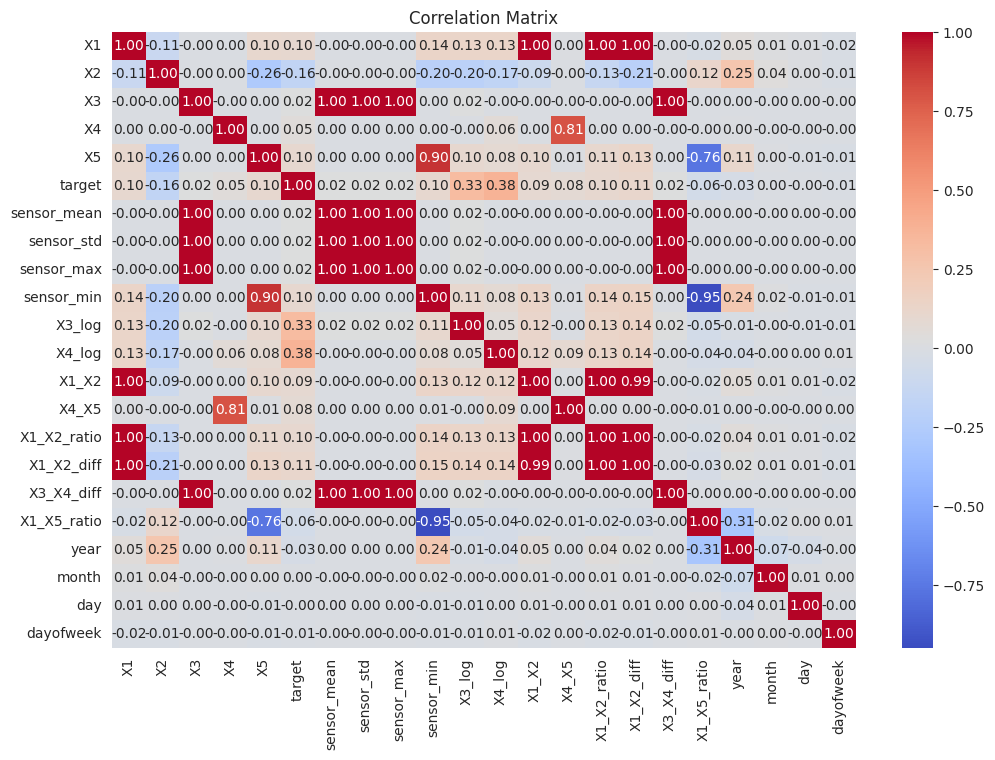

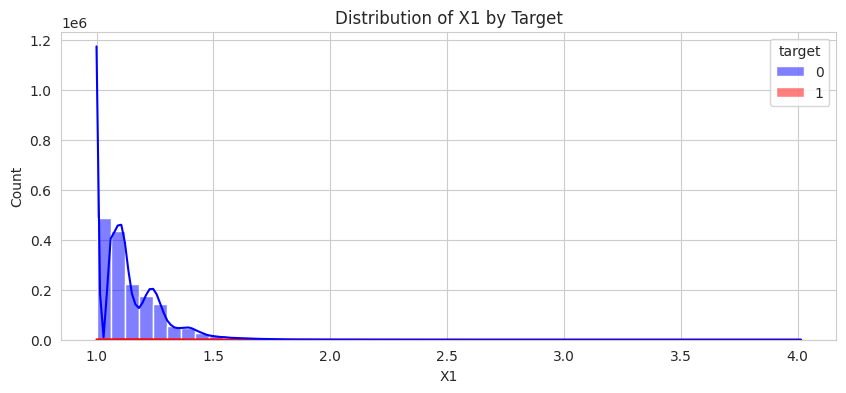

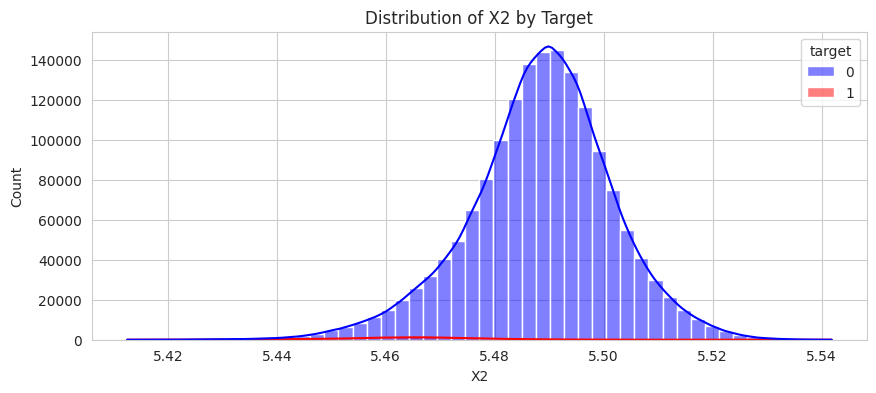

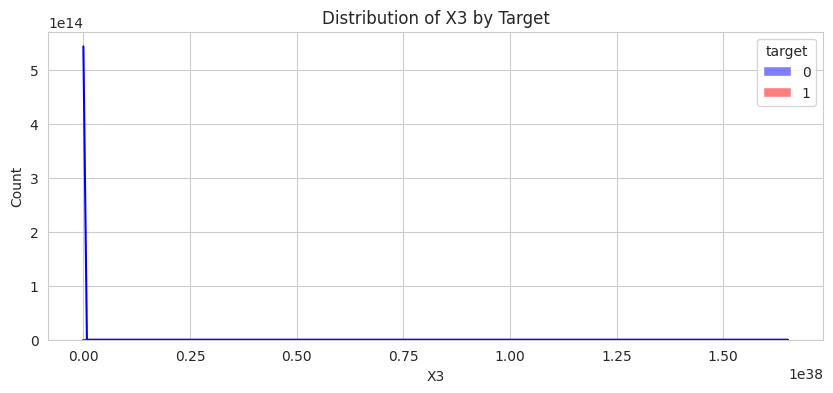

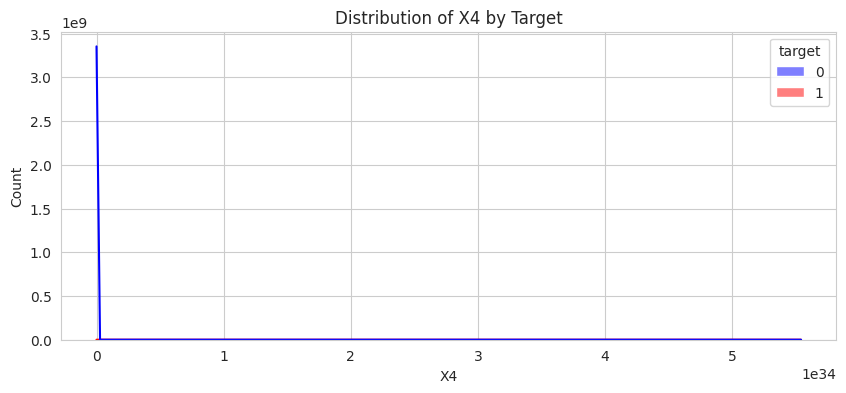

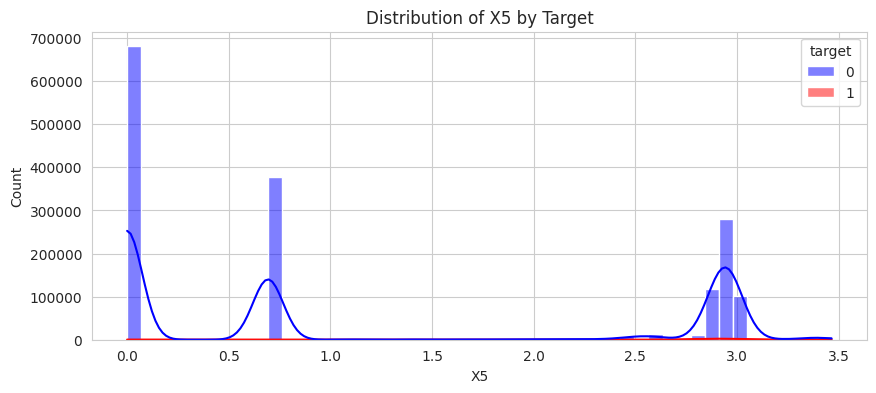

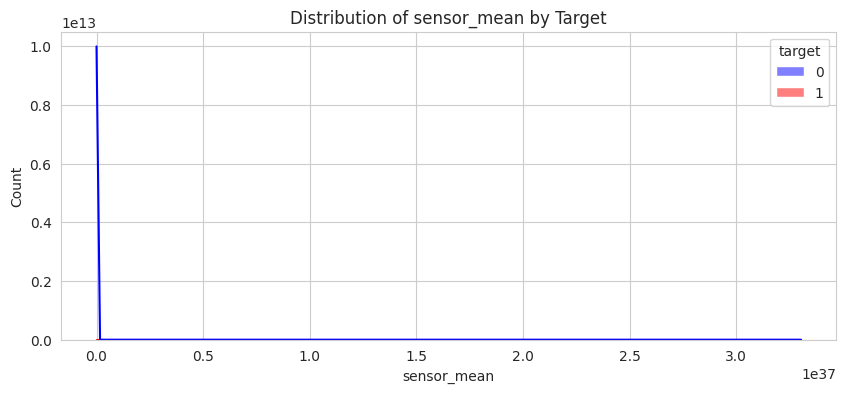

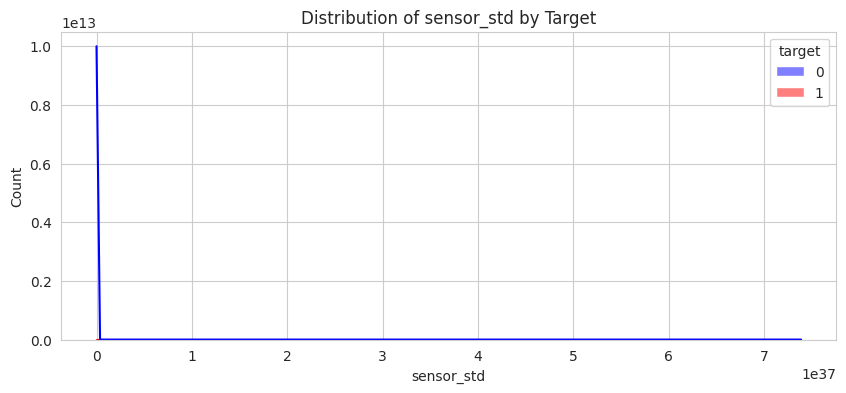

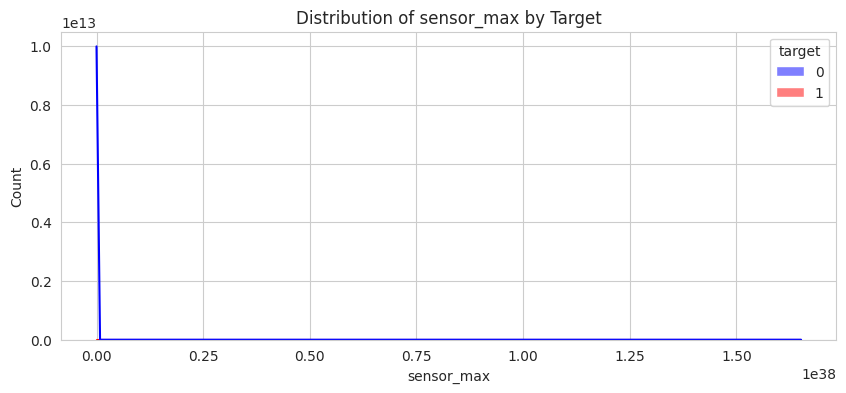

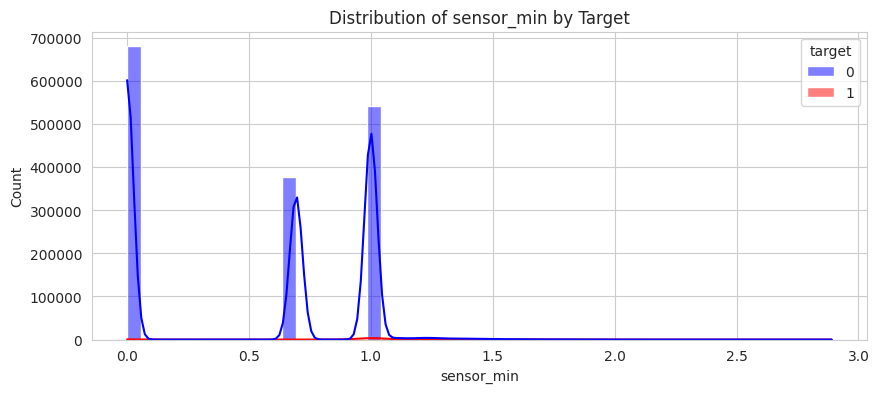

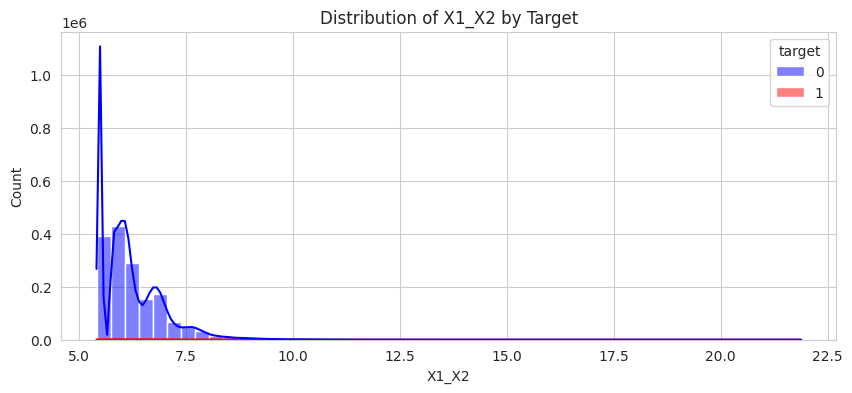

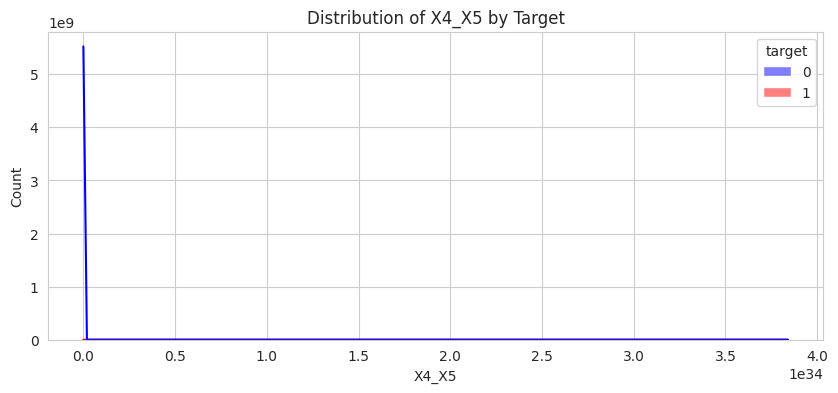

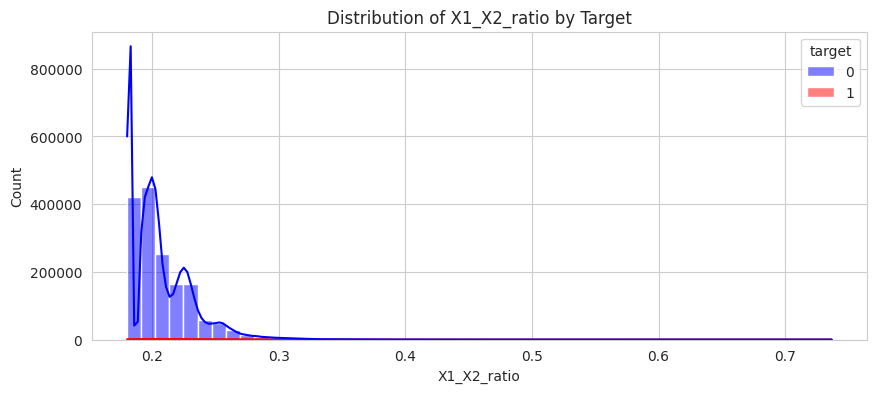

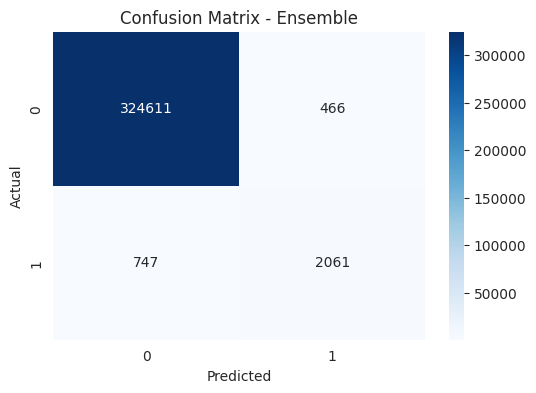

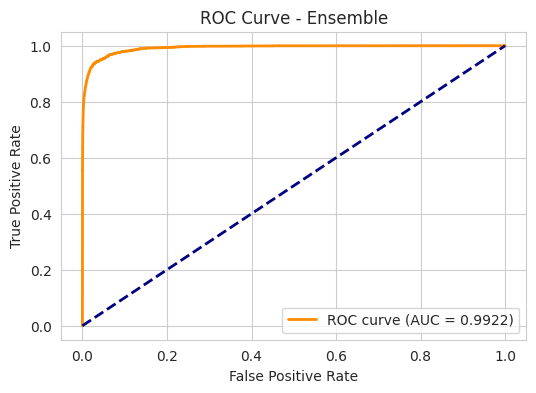

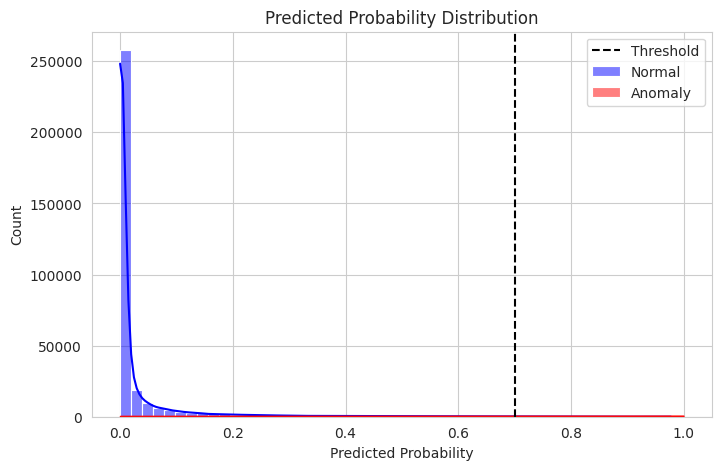

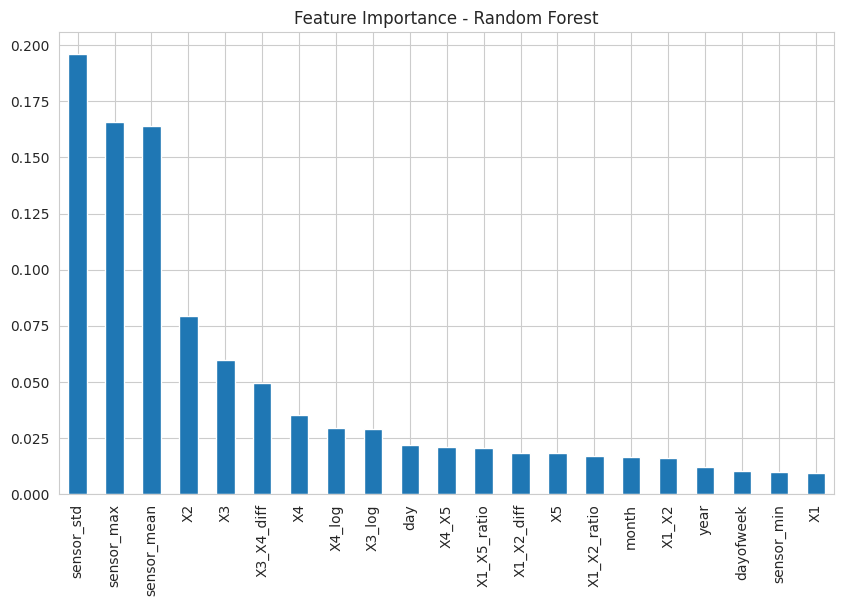

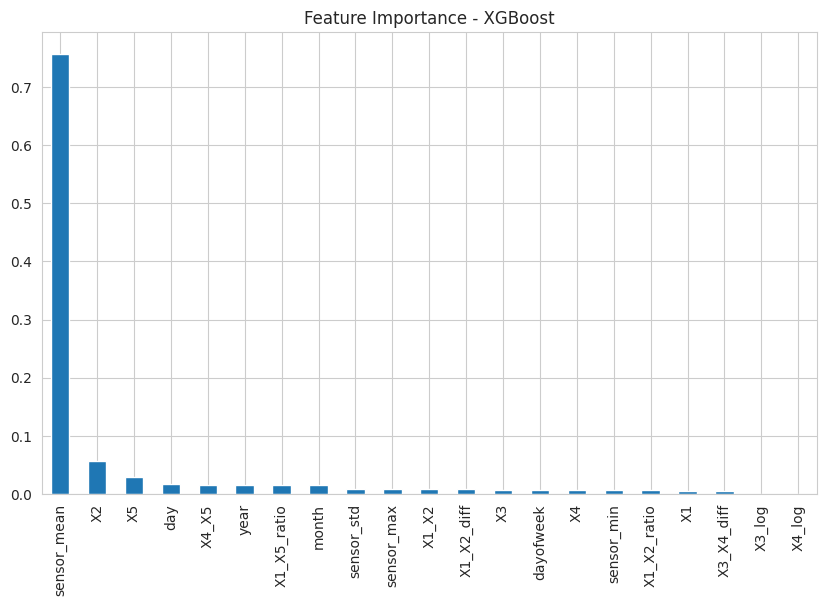

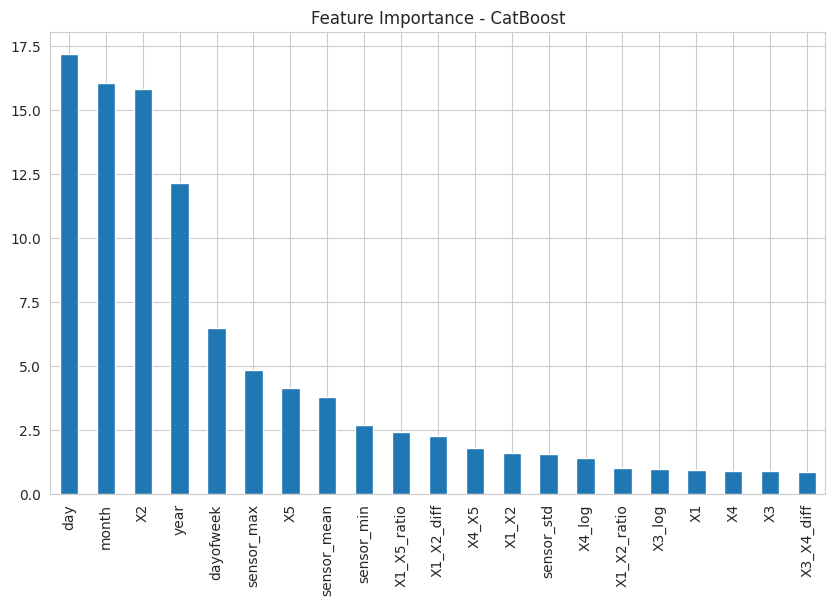

In [ ]:
# =========================================
# Complete Visualization Dashboard
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set_style('whitegrid')

# ------------------------------
# 1️⃣ Correlation Matrix
# ------------------------------
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix")
plt.show()

# ------------------------------
# 2️⃣ Feature Distributions by Target
# ------------------------------
all_features = ['X1','X2','X3','X4','X5','sensor_mean','sensor_std','sensor_max','sensor_min','X1_X2','X4_X5','X1_X2_ratio']

for col in all_features:
    plt.figure(figsize=(10,4))
    sns.histplot(data=train, x=col, hue='target', bins=50, kde=True, palette=['blue','red'], alpha=0.5)
    plt.title(f"Distribution of {col} by Target")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# ------------------------------
# 3️⃣ Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble")
plt.show()

# ------------------------------
# 4️⃣ ROC Curve
# ------------------------------
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ensemble")
plt.legend(loc="lower right")
plt.show()

# ------------------------------
# 5️⃣ Predicted Probability Distribution
# ------------------------------
plt.figure(figsize=(8,5))
sns.histplot(y_val_proba[y_val==0], color='blue', label='Normal', bins=50, kde=True)
sns.histplot(y_val_proba[y_val==1], color='red', label='Anomaly', bins=50, kde=True)
plt.axvline(best_threshold, color='black', linestyle='--', label='Threshold')
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

# ------------------------------
# 6️⃣ Feature Importances
# ------------------------------
# Random Forest
rf_feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
rf_feat_imp.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.show()

# XGBoost
xgb_feat_imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
xgb_feat_imp.plot(kind='bar')
plt.title("Feature Importance - XGBoost")
plt.show()

# CatBoost
cat_feat_imp = pd.Series(cat.get_feature_importance(), index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
cat_feat_imp.plot(kind='bar')
plt.title("Feature Importance - CatBoost")
plt.show()

In [ ]:
# =========================================
# CEIP CVR - Enhanced Ensemble with Imputation
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ------------------------------
# 1️⃣ Load Data
# ------------------------------
train_path = '/content/train.parquet'
test_path = '/content/test.parquet'
train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
train['target'] = train['target'].astype(int)

# ------------------------------
# 2️⃣ Feature Engineering
# ------------------------------
epsilon = 1e-10
num_cols = ['X1','X2','X3','X4','X5']

for df in [train, test]:
    df['sensor_mean'] = df[num_cols].mean(axis=1)
    df['sensor_std'] = df[num_cols].std(axis=1)
    df['sensor_max'] = df[num_cols].max(axis=1)
    df['sensor_min'] = df[num_cols].min(axis=1)
    df['X3_log'] = np.log1p(df['X3'] + epsilon)
    df['X4_log'] = np.log1p(df['X4'] + epsilon)
    df['X1_X2'] = df['X1'] * df['X2']
    df['X4_X5'] = df['X4'] * df['X5']
    df['X1_X2_ratio'] = df['X1'] / (df['X2'] + epsilon)
    df['X1_X2_diff'] = df['X1'] - df['X2']
    df['X3_X4_diff'] = df['X3'] - df['X4']
    df['X1_X5_ratio'] = df['X1'] / (df['X5'] + epsilon)
    # Rolling / lag features (window=3)
    for col in num_cols:
        df[f'{col}_roll_mean'] = df[col].rolling(3, min_periods=1).mean()
        df[f'{col}_roll_std'] = df[col].rolling(3, min_periods=1).std()
    # Date features
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek

train.drop('Date', axis=1, inplace=True)
test.drop('Date', axis=1, inplace=True)

features = [c for c in train.columns if c != 'target']

# ------------------------------
# 2️⃣a Impute Missing Values
# ------------------------------
imputer = SimpleImputer(strategy='median')
train[features] = imputer.fit_transform(train[features])
test[features] = imputer.transform(test[features])

# ------------------------------
# 3️⃣ Train-Validation Split
# ------------------------------
X = train[features]
y = train['target']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ------------------------------
# 4️⃣ Train Ensemble Models
# ------------------------------
rf = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=250, learning_rate=0.05, scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(), random_state=42, n_jobs=-1)
cat = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=8, loss_function='Logloss', eval_metric='F1', class_weights=[1,20], verbose=100, random_state=42)
lgb = LGBMClassifier(n_estimators=250, learning_rate=0.05, class_weight='balanced', random_state=42, n_jobs=-1)
mlp = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', max_iter=500, random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
cat.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=100)
lgb.fit(X_train, y_train)
mlp.fit(X_train, y_train)

# ------------------------------
# 5️⃣ Ensemble Predictions (Validation)
# ------------------------------
y_val_proba = (rf.predict_proba(X_val)[:,1] +
               xgb.predict_proba(X_val)[:,1] +
               cat.predict_proba(X_val)[:,1] +
               lgb.predict_proba(X_val)[:,1] +
               mlp.predict_proba(X_val)[:,1]) / 5

# Optimize threshold
thresholds = np.arange(0.1, 1.0, 0.01)
best_f1 = 0
best_threshold = 0
for t in thresholds:
    y_pred_t = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
print(f"Optimal Threshold: {best_threshold}, Best F1: {best_f1:.4f}")

# Final predictions
y_val_pred = (y_val_proba >= best_threshold).astype(int)

print("Classification Report (Ensemble):")
print(classification_report(y_val, y_val_pred))

# ------------------------------
# 6️⃣ Predict on Test Set & Create Submission
# ------------------------------
y_test_proba = (rf.predict_proba(test[features])[:,1] +
                xgb.predict_proba(test[features])[:,1] +
                cat.predict_proba(test[features])[:,1] +
                lgb.predict_proba(test[features])[:,1] +
                mlp.predict_proba(test[features])[:,1]) / 5
y_test_pred = (y_test_proba >= best_threshold).astype(int)

submission = pd.DataFrame({'target': y_test_pred})
submission.to_csv("submission.csv", index=False)
print(f"Submission file created with {len(submission)} rows")
display(submission.head())

0:	learn: 0.8623750	test: 0.8722472	best: 0.8722472 (0)	total: 398ms	remaining: 1m 59s
100:	learn: 0.9108854	test: 0.9088992	best: 0.9090350 (97)	total: 44s	remaining: 1m 26s
200:	learn: 0.9268677	test: 0.9165727	best: 0.9168566 (195)	total: 1m 26s	remaining: 42.7s
299:	learn: 0.9370860	test: 0.9215157	best: 0.9220688 (296)	total: 2m 8s	remaining: 0us

bestTest = 0.9220687623
bestIteration = 296

Shrink model to first 297 iterations.
[LightGBM] [Info] Number of positive: 11230, number of negative: 1300309
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.184796 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5811
[LightGBM] [Info] Number of data points in the train set: 1311539, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Op

,target
0,0
1,0
2,0
3,0
4,1


0:	learn: 0.8657775	test: 0.8756254	best: 0.8756254 (0)	total: 396ms	remaining: 1m 58s
100:	learn: 0.9107486	test: 0.9103380	best: 0.9103380 (100)	total: 42.6s	remaining: 1m 23s
200:	learn: 0.9261649	test: 0.9164263	best: 0.9165831 (195)	total: 1m 27s	remaining: 43.3s
299:	learn: 0.9371018	test: 0.9194292	best: 0.9194457 (294)	total: 2m 9s	remaining: 0us

bestTest = 0.9194456862
bestIteration = 294

Shrink model to first 295 iterations.
Optimal Threshold: 0.7000000000000002, Best F1: 0.7613

Classification Report (Ensemble)
              precision    recall  f1-score   support

           0     0.9976    0.9985    0.9980    325077
           1     0.8040    0.7229    0.7613      2808

    accuracy                         0.9961    327885
   macro avg     0.9008    0.8607    0.8797    327885
weighted avg     0.9960    0.9961    0.9960    327885



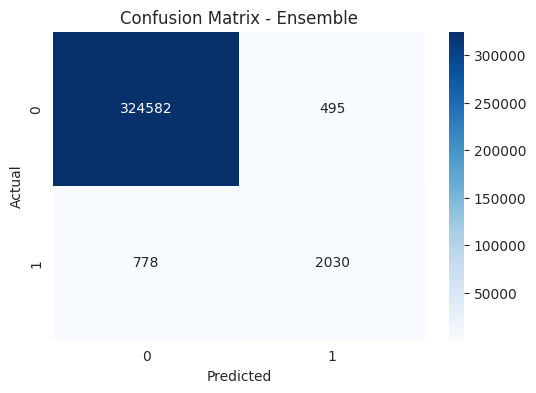

F1 Score for Anomalies: 0.7613
ROC AUC: 0.9951
Submission file created with 409856 rows


,ID,target
0,0,0
1,1,0
2,2,0
3,3,0
4,4,1


In [ ]:
# ================================
# CEIP CVR - Optimized Anomaly Detection
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ------------------------------
# 1️⃣ Load Data
# ------------------------------
train_path = '/content/train.parquet'
test_path  = '/content/test.parquet'

train = pd.read_parquet(train_path)
test  = pd.read_parquet(test_path)

train['target'] = train['target'].astype(int)

# ------------------------------
# 2️⃣ Robust Feature Engineering
# ------------------------------
epsilon = 1e-10
num_cols = ['X1','X2','X3','X4','X5']

for df in [train, test]:
    # 1️⃣ Rolling stats
    for col in num_cols:
        df[f'{col}_roll_mean'] = df[col].rolling(3, min_periods=1).mean()
        df[f'{col}_roll_std']  = df[col].rolling(3, min_periods=1).std()

    # 2️⃣ Aggregated sensor stats
    df['sensor_mean'] = df[num_cols].mean(axis=1)
    df['sensor_std']  = df[num_cols].std(axis=1)
    df['sensor_max']  = df[num_cols].max(axis=1)
    df['sensor_min']  = df[num_cols].min(axis=1)

    # 3️⃣ Log transforms
    df['X3_log'] = np.log1p(df['X3'] + epsilon)
    df['X4_log'] = np.log1p(df['X4'] + epsilon)

    # 4️⃣ Interactions & ratios
    df['X1_X2']       = df['X1'] * df['X2']
    df['X4_X5']       = df['X4'] * df['X5']
    df['X1_X2_ratio'] = df['X1'] / (df['X2'] + epsilon)
    df['X1_X2_diff']  = df['X1'] - df['X2']
    df['X3_X4_diff']  = df['X3'] - df['X4']
    df['X1_X5_ratio'] = df['X1'] / (df['X5'] + epsilon)

    # 5️⃣ Datetime features
    if 'Date' in df.columns:
        df['year']      = df['Date'].dt.year
        df['month']     = df['Date'].dt.month
        df['day']       = df['Date'].dt.day
        df['dayofweek'] = df['Date'].dt.dayofweek
        df.drop('Date', axis=1, inplace=True)

    # 6️⃣ Fill NaNs from rolling std
    df.fillna(0, inplace=True)

# ------------------------------
# 3️⃣ Train-Validation Split
# ------------------------------
features = [c for c in train.columns if c != 'target']

X = train[features]
y = train['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ------------------------------
# 4️⃣ Model Training - Ensemble
# ------------------------------
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

xgb = XGBClassifier(n_estimators=200, learning_rate=0.05,
                    scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
                    random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

cat = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=8,
                         loss_function='Logloss', eval_metric='F1',
                         class_weights=[1,20], verbose=100, random_state=42)
cat.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=100)

# ------------------------------
# 5️⃣ Ensemble Predictions on Validation
# ------------------------------
rf_val_proba = rf.predict_proba(X_val)[:,1]
xgb_val_proba = xgb.predict_proba(X_val)[:,1]
cat_val_proba = cat.predict_proba(X_val)[:,1]

y_val_proba = (rf_val_proba + xgb_val_proba + cat_val_proba)/3

# Threshold tuning
thresholds = np.arange(0.1, 1.0, 0.05)
best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_t = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Optimal Threshold: {best_threshold}, Best F1: {best_f1:.4f}")

# ------------------------------
# 6️⃣ Evaluate Ensemble on Validation
# ------------------------------
y_val_pred = (y_val_proba >= best_threshold).astype(int)

print("\nClassification Report (Ensemble)")
print(classification_report(y_val, y_val_pred, digits=4))

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble")
plt.show()

f1_anomaly = f1_score(y_val, y_val_pred, pos_label=1)
auc = roc_auc_score(y_val, y_val_proba)

print(f"F1 Score for Anomalies: {f1_anomaly:.4f}")
print(f"ROC AUC: {auc:.4f}")

# ------------------------------
# 7️⃣ Predict on Test Set & Submission
# ------------------------------
rf_test_proba = rf.predict_proba(test[features])[:,1]
xgb_test_proba = xgb.predict_proba(test[features])[:,1]
cat_test_proba = cat.predict_proba(test[features])[:,1]

y_test_proba = (rf_test_proba + xgb_test_proba + cat_test_proba)/3
y_test_pred = (y_test_proba >= best_threshold).astype(int)

# Include ID column if it exists
if 'ID' in test.columns:
    submission = pd.DataFrame({'ID': test['ID'], 'target': y_test_pred})
else:
    submission = pd.DataFrame({'target': y_test_pred})

submission.to_csv("submission1.csv", index=False)
print(f"Submission file created with {len(submission)} rows")
display(submission.head())